In [1]:
# анализ показателя Херста
# фрактального броуновского
# движения методом накопленной дисперсии

# Ячейка № 1

# подключение библиотеки numpy
import numpy as np

# подключение библиотеки matplotlib.pyplot
import matplotlib.pyplot as plt

# подключение библиотеки random
import random

# подключение функций fft, fftfreq
from scipy.fft import fft

# подключение библиотеки scipy.stats
import scipy.stats as sps

# инициализация генератора
# случайных чисел
random.seed()


In [2]:
# Ячейка № 2

# задание функции, возвращающей
# оценку показателя Херста и
# соответствующие статистики
# в соответствие с методом
# накопленной дисперсии
def Cum_Disp(X, N_Start, T_max, L, DrawPlot):
    # входные переменные:
    # X - координаты траектории
    #     фрактального броуновского движения
    # N_Start - номер начального элемента массива Х,
    #           используемого для вычисления оценки
    #           показателя Херста
    # T_max - максимальная длительность
    #         отрезка delta_t
    # L - число элементов массива Х,
    #     используемых для вычисления оценок
    #     показателей  Херста
    # DrawPlot - логическая переменная,
    #            DrawPlot = True/False - включение/выключение
    #            режима визуализации ФДБ и
    #            результатов вычисления
    #            показателя Херста

    # вычисление максимального номера
    # элемента массива X, используемого
    # для вычисления оценки
    # показателя Херста
    N_Finish = N_Start + L + T_max

    # корректировка значения N_Finish,
    # если N_Finish > len(X)
    if N_Finish > len(X):
        N_Finish = len(X) - T_max

    # инициализация массива dX
    dX = np.zeros(N_Finish)

    # инициализация массива Sigma_RMS
    Sigma_RMS = np.zeros(T_max)

    # инициализация массива dT
    dt = np.zeros(T_max)

    # вычисление значений зависимости
    # [log2(t_2 - t_1), log2(X[t_2] - X[t_1])]
    for p in range(1, T_max + 1):
        for i in range(N_Start, N_Finish - p):
            dX[i - N_Start] = X[i + p] - X[i]
        Sigma_RMS[p - 1] = np.log2(np.std(dX[:]))
        dt[p - 1] = np.log2(p)

    # вычисление коэффициентов
    # линейной аппроксимации зависимости
    # [log2(t_2 - t_1), log2(X[t_2] - X[t_1])]
    # и статистики линейной регрессии
    n = len(dt)
    lin_model = sps.linregress(dt, Sigma_RMS)

    # вычисление параметров линейной регрессии
    a, b = lin_model.slope, lin_model.intercept

    # вычисление погрешности коэффицентов линейной регрессии
    a_err, b_err = lin_model.stderr, lin_model.intercept_stderr

    # вычисление доверительных интервалов линейной регрессии
    # с доверительной вероятностью 0.95
    a_conf = sps.t.interval(0.95, df=n - 2, loc=a, scale=a_err)
    b_conf = sps.t.interval(0.95, df=n - 2, loc=b, scale=b_err)

    if DrawPlot:
        # задание вида
        # аппроксимирующей функции
        def MK_Model(a, b):
            return lambda x: a * x + b

        # визуализация значений
        # зависимости [log2(t_2 - t_1), log2(X[t_2] - X[t_1])] и
        # результатов ее линейной аппроксимации
        plt.figure(figsize=(11, 5))

        ax = plt.subplot(1, 2, 1)
        plt.plot(X, "-k", lw=1)
        plt.grid(True)

        ax = plt.subplot(1, 2, 2)
        ax.scatter(dt, Sigma_RMS, s=3, color="black")
        ax.plot(dt, MK_Model(a, b)(dt), "-k", lw=1)
        ax.plot(dt, MK_Model(a_conf[0], b_conf[0])(dt), "--k", lw=1)
        ax.plot(dt, MK_Model(a_conf[1], b_conf[1])(dt), "--k", lw=1)
        ax.grid(True)

        plt.show()

        print(
            f"a = {a:0.4f} ± {a_err:0.4f}, \
       95%-ый доверительный интервал: [{a_conf[0]:0.4f} ; {a_conf[1]:0.4f}]"
        )
        print(" ")
        print(
            f"b = {b:0.4f} ± {b_err:0.4f}, \
       95%-ый доверительный интервал: [{b_conf[0]:0.4f} ; {b_conf[1]:0.4f}]"
        )

    return a, b, a_err, b_err, a_conf, b_conf

In [3]:
# Ячейка № 3

# задание функции,
# возвращающей координаты
# траектории фрактального
# броуновского движения,
# вычисленные на основе Фурье-фильтрации


def FBM_FF(H, Level):
    # входные переменные:
    # H - показатель Херста
    # Level - показатель степени числа 2

    # вычисление длины траектории
    N = 2**Level

    # инициализация комплекснозначного массива
    X = np.zeros(N) * 1j

    # вычисление координаты
    # начальной точки траектории
    X[0] = random.gauss(0, 1)

    # вычисление координат
    # фрактальной траектории
    # на основе Фурье-фильтрации
    for i in range(1, N // 2 - 1):
        Tmp = random.gauss(0, 1) * np.exp(2 * np.pi * 1j * random.uniform(0, 1))
        X[i] = Tmp / i ** (H + 0.5)
    for i in (N // 2 + 1, N - 1):
        X[i] = np.conj(X[N - i])
    X = fft(X)

    return np.real(X - X[0])

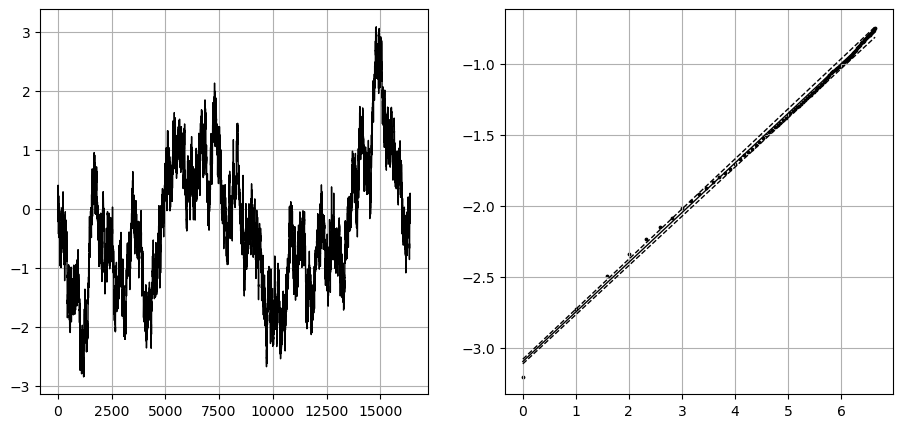

a = 0.3498 ± 0.0015,        95%-ый доверительный интервал: [0.3468 ; 0.3529]
 
b = -3.0964 ± 0.0083,        95%-ый доверительный интервал: [-3.1129 ; -3.0800]


In [4]:
# Ячейка № 4

# задание значений показателя Херста
H1 = 0.3

# задание значения числа n
# (в описании алгоритма)
Max_Level = 14

# вычисление координат траектории ФБД
X1 = FBM_FF(H1, Max_Level)

N_Start = 0
T_max = 100
L = 4000
a_1, b_1, a_err_1, b_err_1, a_conf_1, b_conf_1 = Cum_Disp(X1, N_Start, T_max, L, True)


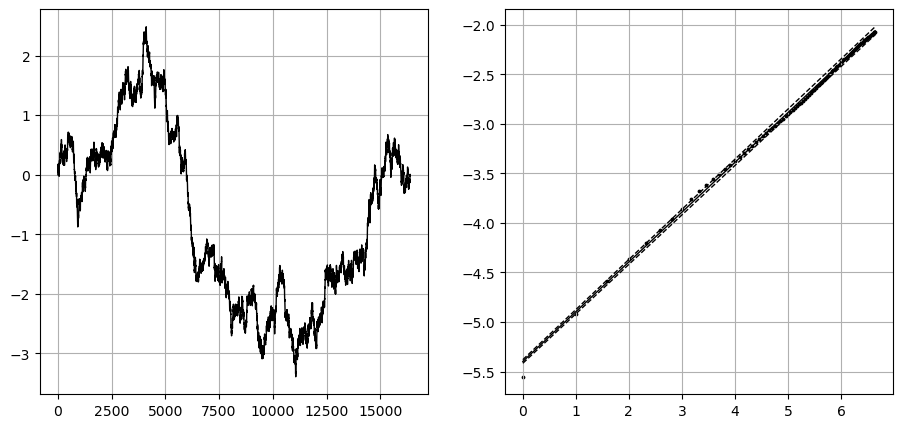

a = 0.5025 ± 0.0017,        95%-ый доверительный интервал: [0.4991 ; 0.5058]
 
b = -5.3981 ± 0.0091,        95%-ый доверительный интервал: [-5.4162 ; -5.3799]


In [5]:
# Ячейка № 5

# задание значений показателя Херста

H2 = 0.5

# задание значения числа n
# (в описании алгоритма)
Max_Level = 14

# вычисление координат траектории ФБД
X2 = FBM_FF(H2, Max_Level)

N_Start = 0
T_max = 100
L = 4000
a_2, b_2, a_err_2, b_err_2, a_conf_2, b_conf_2 = Cum_Disp(X2, N_Start, T_max, L, True)

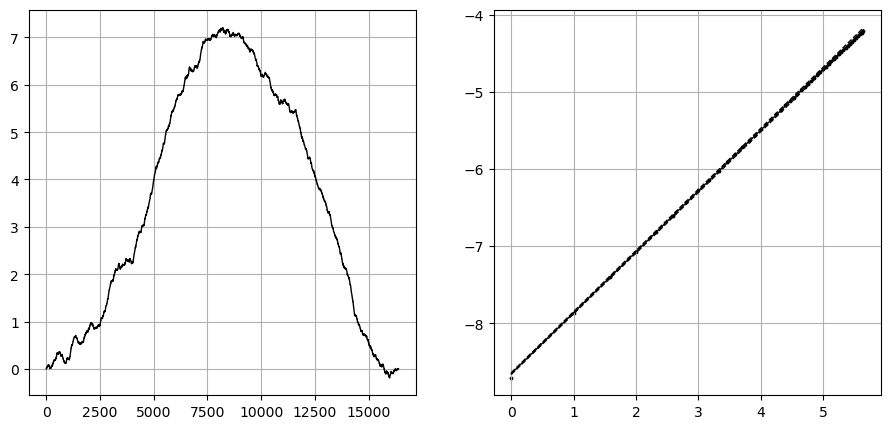

a = 0.7898 ± 0.0013,        95%-ый доверительный интервал: [0.7872 ; 0.7924]
 
b = -8.6544 ± 0.0057,        95%-ый доверительный интервал: [-8.6659 ; -8.6429]


In [6]:
# Ячейка № 6

# задание значений показателя Херста
H3 = 0.8

# задание значения числа n
# (в описании алгоритма)
Max_Level = 14

# вычисление координат траектории ФБД
X3 = FBM_FF(H3, Max_Level)

N_Start = 0
T_max = 50
L = 4000
a_3, b_3, a_err_3, b_err_3, a_conf_3, b_conf_3 = Cum_Disp(X3, N_Start, T_max, L, True)

In [7]:
# задание значений показателя Херста
H3 = 0.8

# задание значения числа n
# (в описании алгоритма)
Max_Level = 14

H = np.array([])
for i in range(200):
    # вычисление координат траектории ФБД
    X3 = FBM_FF(H3, Max_Level)

    N_Start = 0
    T_max = 50
    L = 4000
    a_3, b_3, a_err_3, b_err_3, a_conf_3, b_conf_3 = Cum_Disp(
        X3, N_Start, T_max, L, False
    )
    H = np.append(H, a_3)

(array([ 1.,  0.,  3.,  8.,  2.,  9., 17., 16., 16., 20., 26., 29., 20.,
        19.,  3.,  6.,  1.,  2.,  0.,  2.]),
 array([0.69190967, 0.70082293, 0.70973618, 0.71864944, 0.72756269,
        0.73647595, 0.7453892 , 0.75430246, 0.76321571, 0.77212897,
        0.78104223, 0.78995548, 0.79886874, 0.80778199, 0.81669525,
        0.8256085 , 0.83452176, 0.84343501, 0.85234827, 0.86126152,
        0.87017478]),
 <BarContainer object of 20 artists>)

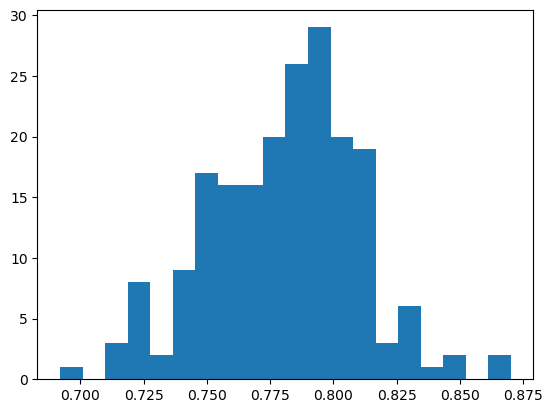

In [8]:
plt.hist(H, 20)